In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
    confusion_matrix,
    ConfusionMatrixDisplay
)
# importing libraries

In [4]:
# Read the first provided dataset (diabetes.csv)
df = pd.read_csv("diabetes.csv")


In [5]:
# x is inputs
# y is ouput/determination
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [6]:
# splits data: 80% training, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=15,
    stratify=y #keeps ratio of positive/negative roughly equal in test/training set
)

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
# Create logistic regression classifier
model = SGDClassifier(
    loss="log_loss",
    penalty=None, # no penalty yet
    learning_rate="constant",
    eta0=0.01,
    random_state=15
)

epochs = 100

train_losses = []
train_accuracies = []

classes = np.unique(y_train)

for epoch in range(epochs):
    model.partial_fit(X_train_scaled, y_train, classes=classes)

    # Predictions and probabilities on training data
    y_train_pred = model.predict(X_train_scaled)
    y_train_prob = model.predict_proba(X_train_scaled)

    # Record loss and accuracy
    loss = log_loss(y_train, y_train_prob)
    accuracy = accuracy_score(y_train, y_train_pred)

    train_losses.append(loss)
    train_accuracies.append(accuracy)

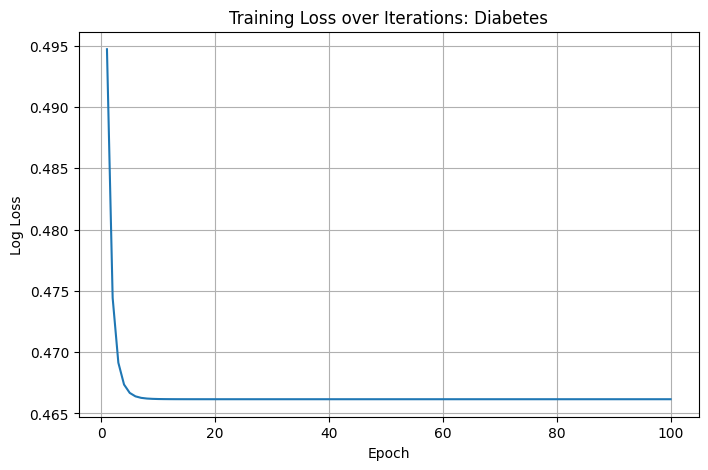

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, epochs + 1), train_losses)

plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Training Loss over Iterations: Diabetes")
plt.grid(True)

plt.show()

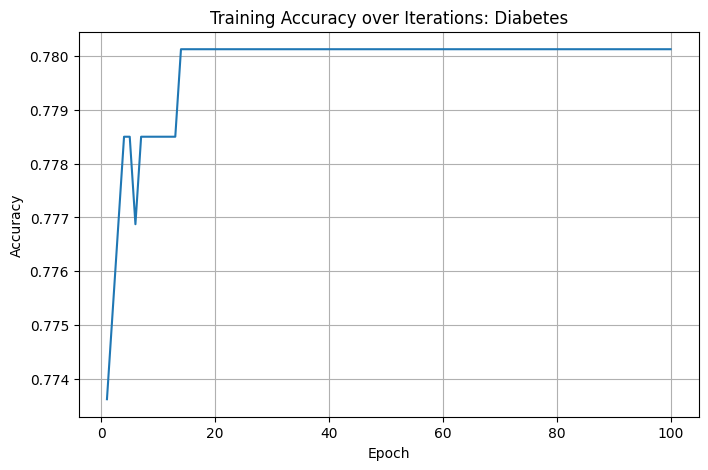

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, epochs + 1), train_accuracies)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy over Iterations: Diabetes")
plt.grid(True)

plt.show()

In [11]:
# Predictions on test data
y_test_pred = model.predict(X_test_scaled)

# Calculate evaluation metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1 Score:  {test_f1:.4f}")

Accuracy:  0.7597
Precision: 0.7073
Recall:    0.5370
F1 Score:  0.6105


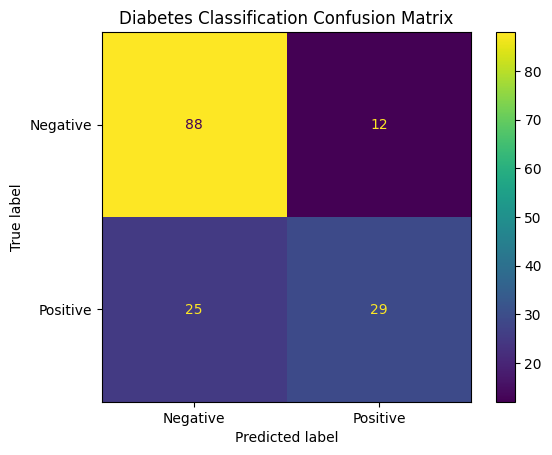

In [12]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Diabetes Classification Confusion Matrix")
plt.show()

In [13]:
#Problem 2: cancer

# read second input file: Cancer
df2 = pd.read_csv("Cancer.csv")



In [14]:
# Separate inputs and output
X2 = df2.drop(["id", "diagnosis", "Unnamed: 32"], axis=1)
y2 = df2["diagnosis"]

In [15]:
# Encode diagnosis labels
# malignant m = 1, benign b = 0
y2 = y2.map({"M": 1, "B": 0})

print(X2.shape)
print(y2.value_counts())

(569, 30)
diagnosis
0    357
1    212
Name: count, dtype: int64


In [16]:
# 80% training, 20% testing
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2,
    y2,
    test_size=0.20,
    random_state=15,
    stratify=y2 # even representation between training and test sets
)

In [17]:
# Standardize features
scaler = StandardScaler()

X_train_scaled2 = scaler.fit_transform(X_train2)
X_test_scaled2 = scaler.transform(X_test2)

In [18]:
model = SGDClassifier(
    loss="log_loss",
    penalty=None,
    learning_rate="constant",
    eta0=0.01,
    random_state=15
)

epochs = 100

train_losses = []
train_accuracies = []

classes = np.unique(y_train2)

for epoch in range(epochs):
    model.partial_fit(X_train_scaled2, y_train2, classes=classes)

    # Predictions and probabilities on training data
    y_train_pred2 = model.predict(X_train_scaled2)
    y_train_prob2 = model.predict_proba(X_train_scaled2)

    # Record loss and accuracy
    loss = log_loss(y_train2, y_train_prob2)
    accuracy = accuracy_score(y_train2, y_train_pred2)

    train_losses.append(loss)
    train_accuracies.append(accuracy)

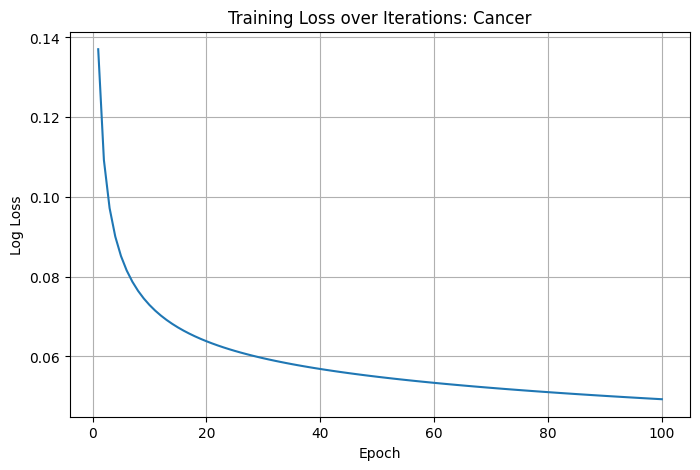

In [19]:
# cancer plot with no penalties
plt.figure(figsize=(8, 5))

plt.plot(range(1, epochs + 1), train_losses)

plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Training Loss over Iterations: Cancer")
plt.grid(True)

plt.show()

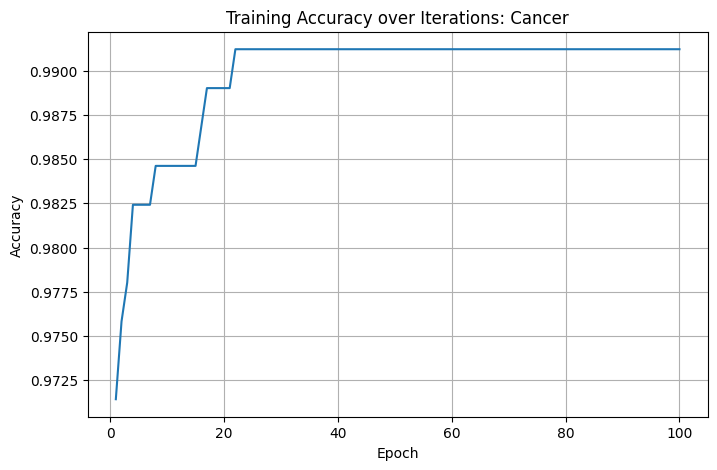

In [20]:
# accuracy plot cancer no penalties

plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_accuracies)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy over Iterations: Cancer")
plt.grid(True)

plt.show()

In [21]:
# Predictions on test data
y_test_pred2 = model.predict(X_test_scaled2)

# Calculate evaluation metrics
test_accuracy2 = accuracy_score(y_test2, y_test_pred2)
test_precision2 = precision_score(y_test2, y_test_pred2)
test_recall2 = recall_score(y_test2, y_test_pred2)
test_f12 = f1_score(y_test2, y_test_pred2)

print(f"Accuracy:  {test_accuracy2:.4f}")
print(f"Precision: {test_precision2:.4f}")
print(f"Recall:    {test_recall2:.4f}")
print(f"F1 Score:  {test_f12:.4f}")

Accuracy:  0.9737
Precision: 1.0000
Recall:    0.9286
F1 Score:  0.9630


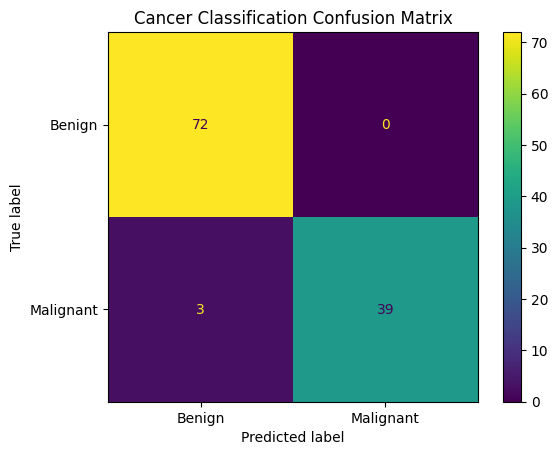

In [22]:
# Create confusion matrix
cm2 = confusion_matrix(y_test2, y_test_pred2)

disp2 = ConfusionMatrixDisplay(
    confusion_matrix=cm2,
    display_labels=["Benign", "Malignant"]
)

disp2.plot()
plt.title("Cancer Classification Confusion Matrix")
plt.show()

In [23]:
# Logistic regression with L2 weight penalty
model_l2 = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha=0.0001,
    learning_rate="constant",
    eta0=0.01,
    random_state=15
)

epochs_l2 = 100

train_losses_l2 = []
train_accuracies_l2 = []

classes_l2 = np.unique(y_train2)

for epoch in range(epochs_l2):
    model_l2.partial_fit(
        X_train_scaled2,
        y_train2,
        classes=classes_l2
    )

    # Predictions and probabilities on training data
    y_train_pred_l2 = model_l2.predict(X_train_scaled2)
    y_train_prob_l2 = model_l2.predict_proba(X_train_scaled2)

    # Record training loss and accuracy
    loss_l2 = log_loss(y_train2, y_train_prob_l2)
    accuracy_l2 = accuracy_score(y_train2, y_train_pred_l2)

    train_losses_l2.append(loss_l2)
    train_accuracies_l2.append(accuracy_l2)

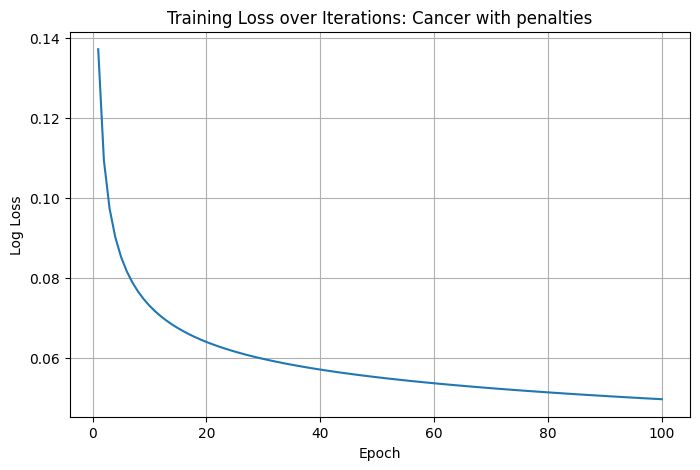

In [24]:
# training loss plot for cancer with L2 penalties
plt.figure(figsize=(8, 5))

plt.plot(range(1, epochs_l2 + 1), train_losses_l2)

plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Training Loss over Iterations: Cancer with penalties")
plt.grid(True)

plt.show()

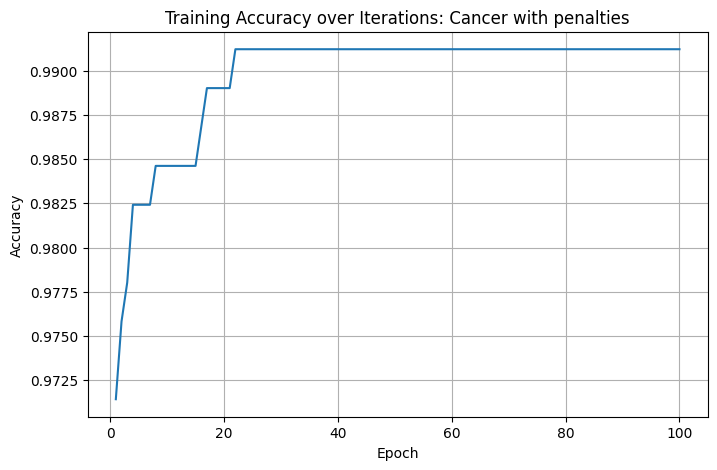

In [25]:
# accuracy plot, cancer with L2 penalties

plt.figure(figsize=(8, 5))

plt.plot(range(1, epochs_l2 + 1), train_accuracies_l2)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy over Iterations: Cancer with penalties")
plt.grid(True)

plt.show()

In [26]:
# Predictions on test data using L2 model
y_test_pred_l2 = model_l2.predict(X_test_scaled2)

# Calculate evaluation metrics
test_accuracy_l2 = accuracy_score(y_test2, y_test_pred_l2)
test_precision_l2 = precision_score(y_test2, y_test_pred_l2)
test_recall_l2 = recall_score(y_test2, y_test_pred_l2)
test_f1_l2 = f1_score(y_test2, y_test_pred_l2)

print(f"Accuracy:  {test_accuracy_l2:.4f}")
print(f"Precision: {test_precision_l2:.4f}")
print(f"Recall:    {test_recall_l2:.4f}")
print(f"F1 Score:  {test_f1_l2:.4f}")

Accuracy:  0.9737
Precision: 1.0000
Recall:    0.9286
F1 Score:  0.9630


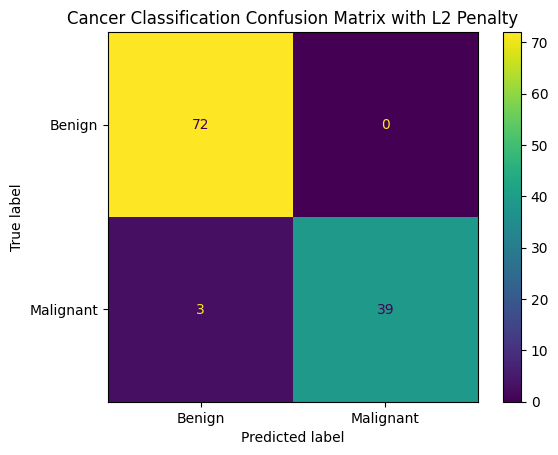

In [27]:
# Create confusion matrix for L2 model
cm_l2 = confusion_matrix(y_test2, y_test_pred_l2)

disp_l2 = ConfusionMatrixDisplay(
    confusion_matrix=cm_l2,
    display_labels=["Benign", "Malignant"]
)

disp_l2.plot()
plt.title("Cancer Classification Confusion Matrix with L2 Penalty")
plt.show()